#  MODELO DE ANÁLISIS — PREDICCIÓN DE INTENSIDAD SÍSMICA
## Catálogo Sísmico Ecuador — TFM Big Data
 Variables optimizadas · Limpieza integrada · 3 modelos comparados

---



---
## 0️⃣ Importaciones

In [24]:
import arcpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 1️⃣ Carga de datos desde GDB

In [25]:
# ── Configuración ──────────────────────────────────────────────────
gdb_path = r"E:\MASTER_BIG_DATA\TFM_FINAL\PROCESOS\GDB_DATA.gdb"
feature_class = "Catalogo_Depurad_SpatialJoin" 

# Todos los campos necesarios para el modelo
fields = [
    "SHAPE@X", "SHAPE@Y",
    "mag",          # Magnitud Mw
    "depth",        # Profundidad km
    "n_replicas",   # Número de réplicas
    "Tipo",         # Tipo de fuente sismogénica
    "MMax",         # Magnitud máxima esperada
    "Strike",       # Parámetro geométrico de falla
    "Rake",         # Parámetro geométrico de falla
    "Dip",          # Parámetro geométrico de falla
    "b",            # Parámetro b Gutenberg-Richter
    "es_mainshock", # ¿Es sismo principal?
    "Depth_rang",   # Rango de profundidad
    "year",         # Año del sismo
    "inten_ajus",   # TARGET — intensidad ajustada (piso=1)
]

data = arcpy.da.FeatureClassToNumPyArray(
    f"{gdb_path}\\{feature_class}",
    fields,
    null_value={
        'Double': np.nan, 'Single': np.nan,
        'Integer': -9999, 'SmallInteger': -9999
    }
)

df = pd.DataFrame(data)
df.rename(columns={"SHAPE@X": "lon", "SHAPE@Y": "lat"}, inplace=True)

print(f'✅ Datos cargados: {df.shape[0]:,} registros | {df.shape[1]} campos')
df.head(3)

✅ Datos cargados: 4,640 registros | 15 campos


,lon,lat,mag,depth,n_replicas,Tipo,MMax,Strike,Rake,Dip,b,es_mainshock,Depth_rang,year,inten_ajus
0,-78.33,0.05,6.4,10.0,0,Crustal Sources,7.3,190,90,55,0.7,TRUE,0-35,1587,8.331
1,-78.80,-1.73,7.0,10.0,0,Crustal Sources,7.9,30,180,90,0.73,TRUE,0-35,1645,9.283
2,-79.05,-1.67,6.4,10.0,0,Islab Sources,8.0,310,-90,70,1.05,TRUE,130-300,1674,5.856


---
## 2️⃣ Preprocesamiento y limpieza integrada

> El modelo es autónomo y reproduce la limpieza internamente.

In [26]:
# ── Reemplazar centinelas ──────────────────────────────────────────
df.replace(-9999, np.nan, inplace=True)

# ── Normalizar texto ───────────────────────────────────────────────
for col in ["Tipo", "es_mainshock", "Depth_rang"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()

# ── Campo 'b' puede venir como texto con asterisco ─────────────────
df["b"] = pd.to_numeric(
    df["b"].astype(str).str.replace(r"[^0-9.\-]", "", regex=True),
    errors="coerce"
)

# ── Transformaciones logarítmicas ──────────────────────────────────
df["depth_log"]      = np.log1p(df["depth"].clip(lower=0))
df["n_replicas_log"] = np.log1p(df["n_replicas"].clip(lower=0))

# ── es_mainshock → binario ─────────────────────────────────────────
df["es_mainshock_bin"] = df["es_mainshock"].apply(
    lambda x: 1 if str(x).strip().lower() in ["true", "1", "yes", "si", "sí", "mainshock"] else 0
)

# ── Depth_rang → ordinal por regex ────────────────────────────────
def mapear_depth_rang(val):
    if pd.isna(val): return np.nan
    nums = re.findall(r'\d+', str(val))
    if not nums: return np.nan
    n = int(nums[0])
    return 0 if n < 35 else 1 if n < 70 else 2 if n < 150 else 3

df["depth_rang_ord"] = df["Depth_rang"].apply(mapear_depth_rang)

print('✅ Preprocesamiento completado')
print(f'   depth_log      → OK | Nulos: {df["depth_log"].isna().sum()}')
print(f'   n_replicas_log → OK | Nulos: {df["n_replicas_log"].isna().sum()}')
print(f'   es_mainshock_bin → distribución: {df["es_mainshock_bin"].value_counts().to_dict()}')
print(f'   depth_rang_ord → distribución: {df["depth_rang_ord"].value_counts().sort_index().to_dict()}')

✅ Preprocesamiento completado
   depth_log      → OK | Nulos: 0
   n_replicas_log → OK | Nulos: 0
   es_mainshock_bin → distribución: {1: 2960, 0: 1680}
   depth_rang_ord → distribución: {0: 3405, 1: 1049, 2: 186}


---
## 3️⃣ Definición de features y target

In [28]:
# ── Features numéricas ─────────────────────────────────────────────
# Seleccionadas por: correlación |r|>0.10 con target + importancia RF

NUM_FEATURES = [
    "MMax",           # r=+0.73
    "Strike",         # r=-0.73
    "Rake",           # r=+0.35
    "Dip",            # r=+0.20, discrimina mecanismo focal
    "lat",            # discriminación espacial
    "lon",            # discriminación espacial
    "n_replicas_log", # r=+0.14 (transformada)
    "year",           # r=-0.12, control temporal
    "es_mainshock_bin",
]

# ── Feature categórica ─────────────────────────────────────────────
CAT_FEATURES = ["Tipo"]   # → One-Hot en el Pipeline

# ── Target ────────────────────────────────────────────────────────
TARGET = "inten_ajus"

# ── Verificar disponibilidad ───────────────────────────────────────
all_features = NUM_FEATURES + CAT_FEATURES
disponibles  = [f for f in all_features if f in df.columns]
faltantes    = [f for f in all_features if f not in df.columns]

if faltantes:
    print(f'⚠️  Campos no encontrados en la GDB: {faltantes}')
    print('   Serán excluidos automáticamente.')
    NUM_FEATURES = [f for f in NUM_FEATURES if f in df.columns]
    CAT_FEATURES = [f for f in CAT_FEATURES if f in df.columns]

print(f'\n✅ Features numéricas : {len(NUM_FEATURES)} → {NUM_FEATURES}')
print(f'✅ Features categóricas: {len(CAT_FEATURES)} → {CAT_FEATURES}')
print(f'✅ Target              : {TARGET}')


✅ Features numéricas : 9 → ['MMax', 'Strike', 'Rake', 'Dip', 'lat', 'lon', 'n_replicas_log', 'year', 'es_mainshock_bin']
✅ Features categóricas: 1 → ['Tipo']
✅ Target              : inten_ajus


In [29]:
# ── Construir X e y ────────────────────────────────────────────────
df_model = df[NUM_FEATURES + CAT_FEATURES + [TARGET]].copy()
df_model = df_model.apply(lambda col: pd.to_numeric(col, errors='coerce')
                          if col.name not in CAT_FEATURES else col)

# Diagnóstico de nulos
nulos = df_model.isnull().sum()
nulos = nulos[nulos > 0]
if not nulos.empty:
    print('⚠️  Nulos detectados:')
    for col, n in nulos.items():
        print(f'   {col:<25}: {n} ({n/len(df_model)*100:.1f}%)')

# Eliminar cols con >50% nulos
cols_ok = [c for c in df_model.columns
           if df_model[c].isnull().mean() <= 0.50]
df_model = df_model[cols_ok]
NUM_FEATURES = [f for f in NUM_FEATURES if f in df_model.columns]

# Imputar nulos restantes con mediana (solo numéricas)
for col in NUM_FEATURES:
    if df_model[col].isnull().sum() > 0:
        df_model[col].fillna(df_model[col].median(), inplace=True)

# Eliminar filas sin target
df_model.dropna(subset=[TARGET], inplace=True)

X = df_model[NUM_FEATURES + CAT_FEATURES]
y = df_model[TARGET]

print(f'\n✅ Dataset final: X={X.shape} | y={y.shape}')
print(f'   Nulos en X: {X.isnull().sum().sum()} | Nulos en y: {y.isnull().sum()}')
print(f'\n📊 Target — inten_ajus:')
print(y.describe().round(3).to_string())


✅ Dataset final: X=(4640, 10) | y=(4640,)
   Nulos en X: 0 | Nulos en y: 0

📊 Target — inten_ajus:
count    4640.000
mean        3.126
std         1.328
min         1.000
25%         2.311
50%         2.832
75%         3.740
max        10.256


---
## 4️⃣ División train / test

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'✅ Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas')
print(f'   Proporción: {X_train.shape[0]/len(X)*100:.0f}% / {X_test.shape[0]/len(X)*100:.0f}%')

✅ Train: 3,712 filas | Test: 928 filas
   Proporción: 80% / 20%


---
## 5️⃣ Definición del preprocesador (Pipeline integrado)

In [31]:
# Pipeline con StandardScaler para numéricas y OneHotEncoder para Tipo
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUM_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_FEATURES)
])

# ── Definición de los 3 modelos en Pipeline ────────────────────────
models = {
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=200, random_state=42, n_jobs=-1
        ))
    ]),
    "SVR": Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", SVR(kernel="rbf", C=10, gamma=0.1))
    ]),
    "MLP Regressor": Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", MLPRegressor(
            hidden_layer_sizes=(128, 64, 32),
            activation="tanh",
            alpha=0.01,
            max_iter=1000,
            random_state=42,
            early_stopping=True,   # evita sobreajuste
            validation_fraction=0.1
        ))
    ])
}

print('✅ Pipelines definidos para: Random Forest | SVR | MLP Regressor')

✅ Pipelines definidos para: Random Forest | SVR | MLP Regressor


---
## 6️⃣ Entrenamiento y evaluación base

In [33]:
results      = {}
predictions  = {}

print(f"{'Modelo':<20} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'CV R² (5-fold)':>20}")
print("-" * 68)

for name, pipeline in models.items():
    # Entrenar
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions[name] = y_pred

    # Métricas en test
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    # Validación cruzada 5-fold en train
    cv_r2 = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2", n_jobs=1)

    results[name] = {
        "MAE": mae, "RMSE": rmse, "R2": r2,
        "CV_R2_mean": cv_r2.mean(), "CV_R2_std": cv_r2.std()
    }

    print(f"{name:<20} {mae:>8.3f} {rmse:>8.3f} {r2:>8.3f} "
          f"  {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

print("\n💡 Nota: R² ~1.0 puede indicar overfitting. Verificar con curvas de aprendizaje.")

Modelo                    MAE     RMSE       R²       CV R² (5-fold)
--------------------------------------------------------------------
Random Forest           0.666    0.949    0.530   0.506 ± 0.022
SVR                     0.721    1.028    0.449   0.358 ± 0.035
MLP Regressor           0.731    1.010    0.468   0.441 ± 0.025

💡 Nota: R² ~1.0 puede indicar overfitting. Verificar con curvas de aprendizaje.


---
## 7️⃣ Visualización — Comparación de métricas base

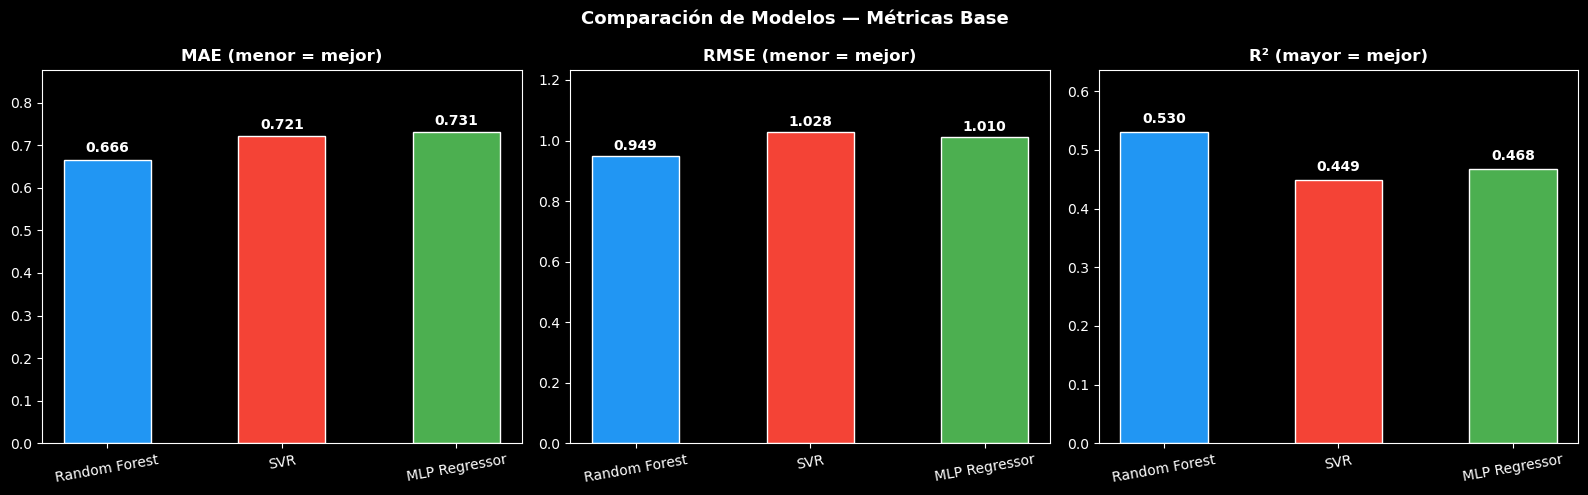

In [34]:
df_results = pd.DataFrame(results).T

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["#2196F3", "#F44336", "#4CAF50"]

for ax, metric, label in zip(
    axes,
    ["MAE", "RMSE", "R2"],
    ["MAE (menor = mejor)", "RMSE (menor = mejor)", "R² (mayor = mejor)"]
):
    bars = ax.bar(df_results.index, df_results[metric],
                  color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, df_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(label, fontweight="bold")
    ax.set_ylim(0, df_results[metric].max() * 1.2)
    ax.tick_params(axis="x", rotation=10)

plt.suptitle("Comparación de Modelos — Métricas Base", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 8️⃣ Valores Reales vs Predichos — 3 modelos

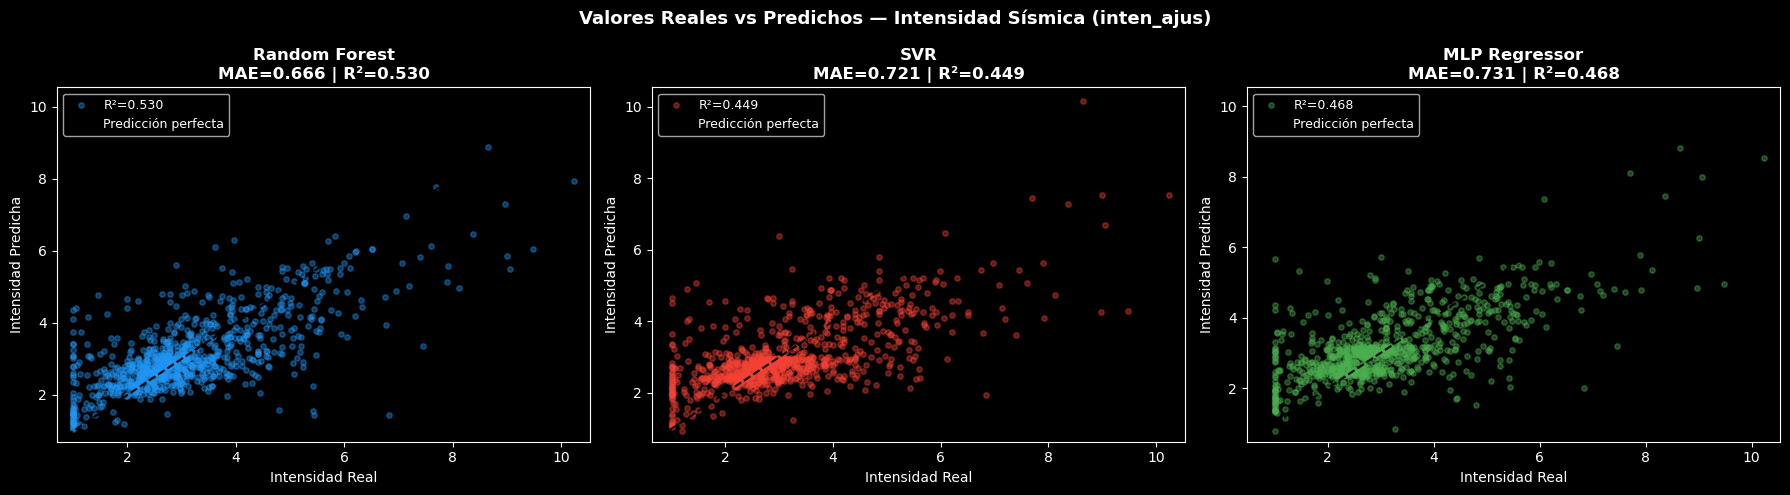

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_colors = {"Random Forest": "#2196F3", "SVR": "#F44336", "MLP Regressor": "#4CAF50"}

for ax, (name, y_pred) in zip(axes, predictions.items()):
    r2 = results[name]["R2"]
    ax.scatter(y_test, y_pred, alpha=0.4, s=15,
               color=model_colors[name], label=f"R²={r2:.3f}")
    lims = [min(y_test.min(), y_pred.min()) - 0.3,
            max(y_test.max(), y_pred.max()) + 0.3]
    ax.plot(lims, lims, "k--", linewidth=1.5, label="Predicción perfecta")
    ax.set_xlabel("Intensidad Real")
    ax.set_ylabel("Intensidad Predicha")
    ax.set_title(f"{name}\nMAE={results[name]['MAE']:.3f} | R²={r2:.3f}",
                 fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_xlim(lims); ax.set_ylim(lims)

plt.suptitle("Valores Reales vs Predichos — Intensidad Sísmica (inten_ajus)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 9️⃣ Distribución de Errores Absolutos

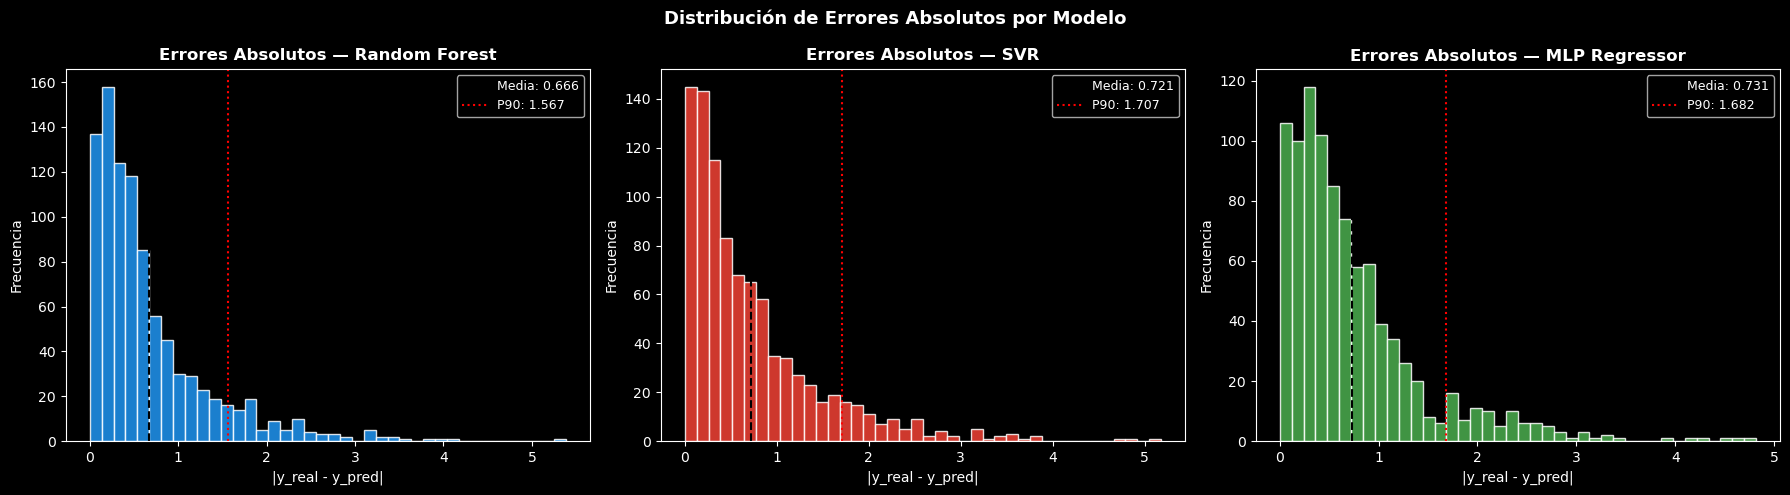

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    errores = np.abs(y_test - y_pred)
    ax.hist(errores, bins=40, color=model_colors[name],
            edgecolor="white", alpha=0.85)
    ax.axvline(errores.mean(), color="black", linestyle="--",
               label=f"Media: {errores.mean():.3f}")
    ax.axvline(np.percentile(errores, 90), color="red", linestyle=":",
               label=f"P90: {np.percentile(errores, 90):.3f}")
    ax.set_title(f"Errores Absolutos — {name}", fontweight="bold")
    ax.set_xlabel("|y_real - y_pred|")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=9)

plt.suptitle("Distribución de Errores Absolutos por Modelo",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 🔟 Importancia de Variables — Random Forest

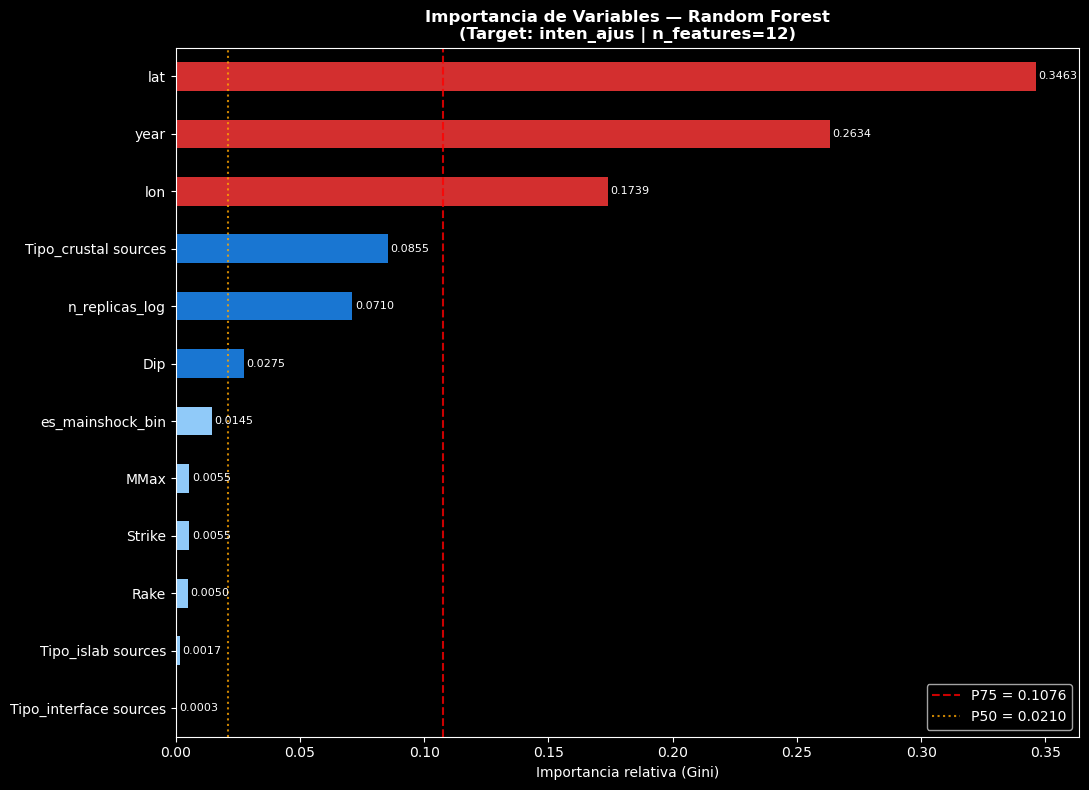


🏆 Ranking de importancia:
lat                       0.3463
year                      0.2634
lon                       0.1739
Tipo_crustal sources      0.0855
n_replicas_log            0.0710
Dip                       0.0275
es_mainshock_bin          0.0145
MMax                      0.0055
Strike                    0.0055
Rake                      0.0050
Tipo_islab sources        0.0017
Tipo_interface sources    0.0003


In [37]:
rf_pipeline = models["Random Forest"]
rf_model    = rf_pipeline.named_steps["regressor"]
preprocessor_fitted = rf_pipeline.named_steps["preprocessor"]

# Nombres de features tras el preprocesador
ohe_cats = preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(CAT_FEATURES)
feature_names = NUM_FEATURES + list(ohe_cats)

importancias = pd.Series(
    rf_model.feature_importances_, index=feature_names
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
colors_imp = ["#D32F2F" if v >= importancias.quantile(0.75)
              else "#1976D2" if v >= importancias.quantile(0.50)
              else "#90CAF9" for v in importancias]

importancias.plot(kind="barh", ax=ax, color=colors_imp)

ax.axvline(importancias.quantile(0.75), color="red", linestyle="--",
           alpha=0.8, label=f"P75 = {importancias.quantile(0.75):.4f}")
ax.axvline(importancias.quantile(0.50), color="orange", linestyle=":",
           alpha=0.8, label=f"P50 = {importancias.quantile(0.50):.4f}")

for i, (val, _) in enumerate(zip(importancias, importancias.index)):
    ax.text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=8)

ax.set_title("Importancia de Variables — Random Forest\n"
             f"(Target: inten_ajus | n_features={len(feature_names)})",
             fontweight="bold")
ax.set_xlabel("Importancia relativa (Gini)")
ax.legend()
plt.tight_layout()
plt.show()

print("\n🏆 Ranking de importancia:")
print(importancias.sort_values(ascending=False).round(4).to_string())

---
## 1️⃣1️⃣ Optimización de Hiperparámetros

In [40]:
# ── Grids de búsqueda ─────────────────────────────────────────────
param_grids = {
    "Random Forest": {
        "regressor__n_estimators":    [100, 200, 300],
        "regressor__max_depth":        [None, 10, 20, 30],
        "regressor__min_samples_split":[2, 5, 10],
        "regressor__min_samples_leaf": [1, 2, 4],
    },
    "SVR": {
        "regressor__C":     [0.1, 1, 10, 100],
        "regressor__gamma": ["scale", 0.01, 0.1, 1],
        "regressor__epsilon":[0.01, 0.1, 0.5],
    },
    "MLP Regressor": {
        "regressor__hidden_layer_sizes": [(64,64), (128,64,32), (256,128,64)],
        "regressor__activation":          ["relu", "tanh"],
        "regressor__alpha":               [0.0001, 0.001, 0.01],
        "regressor__learning_rate_init":  [0.001, 0.01],
    }
}

best_models  = {}
best_params  = {}

for model_name, param_grid in param_grids.items():
    print(f"🔍 Optimizando {model_name}...")

    # RandomizedSearch para MLP (grid muy grande), GridSearch para los demás
    if model_name == "MLP Regressor":
        search = RandomizedSearchCV(
            models[model_name], param_distributions=param_grid,
            n_iter=20, cv=5, scoring="neg_mean_absolute_error",
            n_jobs=1, random_state=42
        )
    else:
        search = GridSearchCV(
            models[model_name], param_grid=param_grid,
            cv=5, scoring="neg_mean_absolute_error",
            n_jobs=1
        )

    search.fit(X_train, y_train)
    best_models[model_name] = search.best_estimator_
    best_params[model_name] = search.best_params_
    print(f"   ✅ Mejor config: {search.best_params_}")
    print(f"   ✅ MAE CV: {-search.best_score_:.4f}\n")

🔍 Optimizando Random Forest...
   ✅ Mejor config: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
   ✅ MAE CV: 0.6435

🔍 Optimizando SVR...
   ✅ Mejor config: {'regressor__C': 10, 'regressor__epsilon': 0.1, 'regressor__gamma': 1}
   ✅ MAE CV: 0.7152

🔍 Optimizando MLP Regressor...
   ✅ Mejor config: {'regressor__learning_rate_init': 0.01, 'regressor__hidden_layer_sizes': (256, 128, 64), 'regressor__alpha': 0.001, 'regressor__activation': 'tanh'}
   ✅ MAE CV: 0.6931



---
## 1️⃣2️⃣ Evaluación de modelos optimizados

In [41]:
results_opt     = {}
predictions_opt = {}

print(f"{'Modelo':<20} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Mejora R²':>12}")
print("-" * 60)

for name, pipeline in best_models.items():
    y_pred_opt = pipeline.predict(X_test)
    predictions_opt[name] = y_pred_opt

    mae  = mean_absolute_error(y_test, y_pred_opt)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_opt))
    r2   = r2_score(y_test, y_pred_opt)

    mejora = r2 - results[name]["R2"]
    results_opt[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

    print(f"{name:<20} {mae:>8.3f} {rmse:>8.3f} {r2:>8.3f} "
          f"  {'+' if mejora>=0 else ''}{mejora:.4f}")

Modelo                    MAE     RMSE       R²    Mejora R²
------------------------------------------------------------
Random Forest           0.653    0.935    0.544   +0.0137
SVR                     0.706    1.048    0.427   -0.0221
MLP Regressor           0.713    1.001    0.478   +0.0099


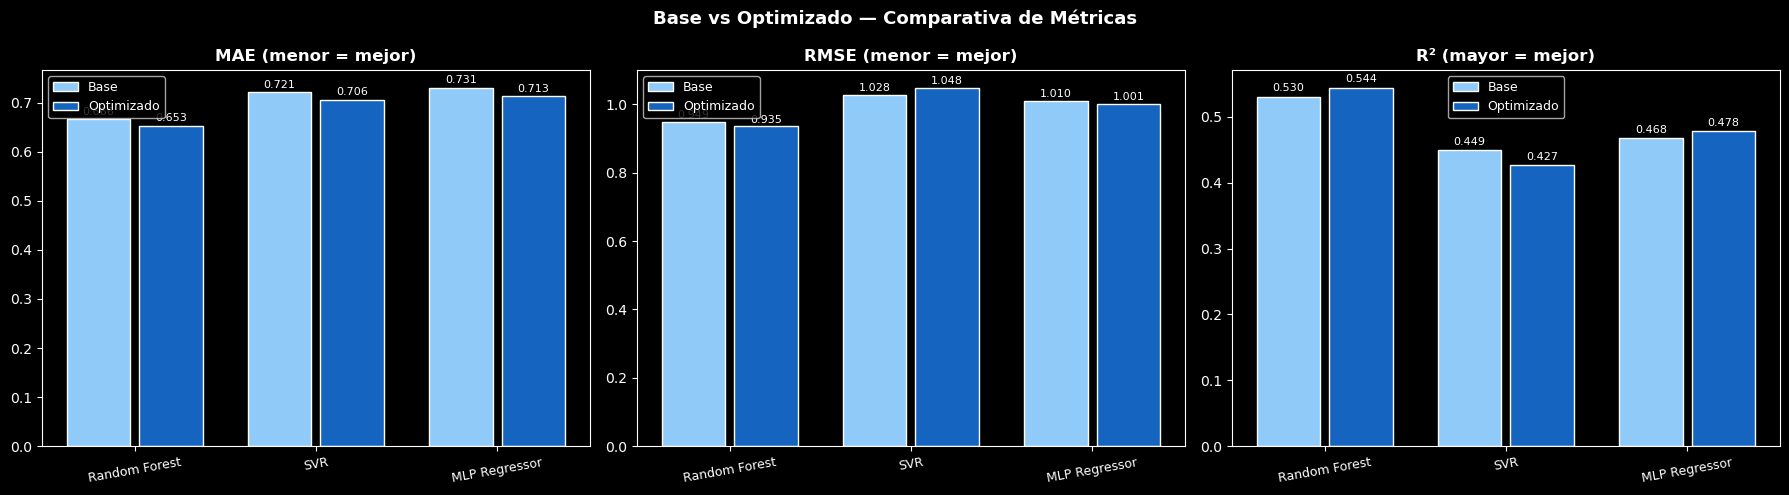

In [42]:
# ── Comparativa base vs optimizado ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_pos   = np.arange(3)
modelos = list(results_opt.keys())

for ax, metric, label in zip(
    axes,
    ["MAE", "RMSE", "R2"],
    ["MAE (menor = mejor)", "RMSE (menor = mejor)", "R² (mayor = mejor)"]
):
    vals_base = [results[m][metric]     for m in modelos]
    vals_opt  = [results_opt[m][metric] for m in modelos]

    bars1 = ax.bar(x_pos - 0.2, vals_base, 0.35,
                   label="Base", color="#90CAF9", edgecolor="white")
    bars2 = ax.bar(x_pos + 0.2, vals_opt,  0.35,
                   label="Optimizado", color="#1565C0", edgecolor="white")

    for bar, val in zip(list(bars1)+list(bars2), vals_base+vals_opt):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(modelos, rotation=10, fontsize=9)
    ax.set_title(label, fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("Base vs Optimizado — Comparativa de Métricas",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 1️⃣3️⃣ Valores Reales vs Predichos — Modelos Optimizados

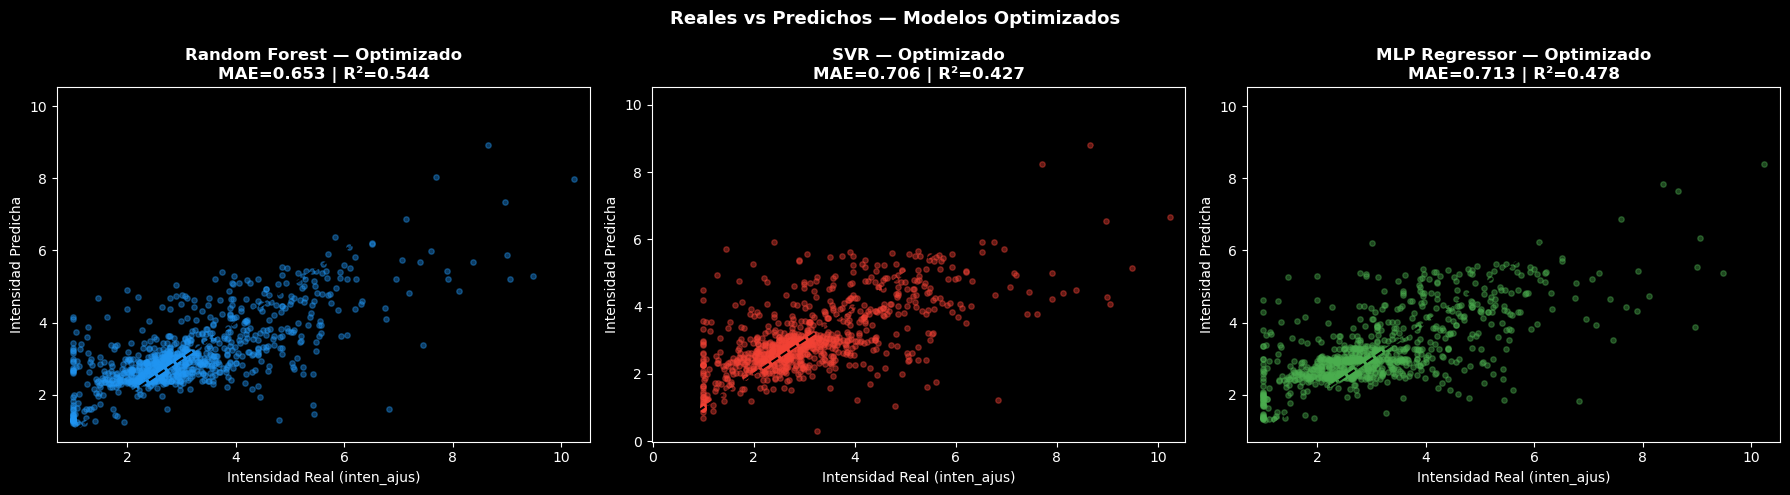

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, predictions_opt.items()):
    r2 = results_opt[name]["R2"]
    ax.scatter(y_test, y_pred, alpha=0.4, s=15,
               color=model_colors[name])
    lims = [min(y_test.min(), y_pred.min()) - 0.3,
            max(y_test.max(), y_pred.max()) + 0.3]
    ax.plot(lims, lims, "k--", linewidth=1.5)
    ax.set_xlabel("Intensidad Real (inten_ajus)")
    ax.set_ylabel("Intensidad Predicha")
    ax.set_title(f"{name} — Optimizado\nMAE={results_opt[name]['MAE']:.3f} | R²={r2:.3f}",
                 fontweight="bold")
    ax.set_xlim(lims); ax.set_ylim(lims)

plt.suptitle("Reales vs Predichos — Modelos Optimizados",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 1️⃣4️⃣ Curvas de Aprendizaje (corregidas)
> **Bug corregido respecto a V1:** el `preprocessor` ya está dentro del Pipeline,
> por lo que `learning_curve` recibe directamente `X` sin transformar.

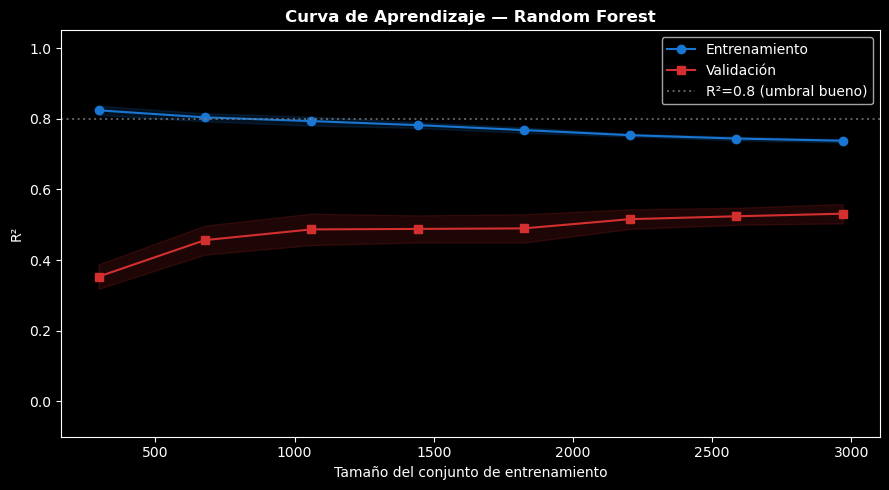

   ⚠️  Random Forest: posible OVERFITTING (gap train-val = 0.206)


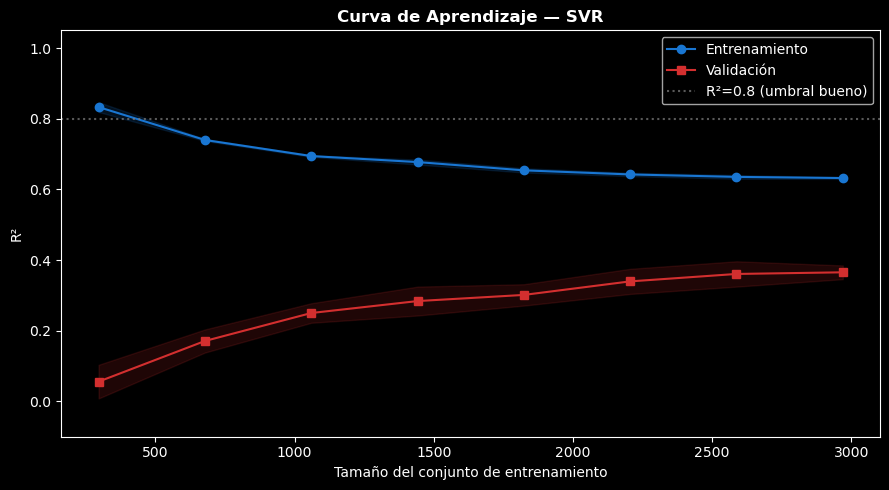

   ⚠️  SVR: posible OVERFITTING (gap train-val = 0.267)


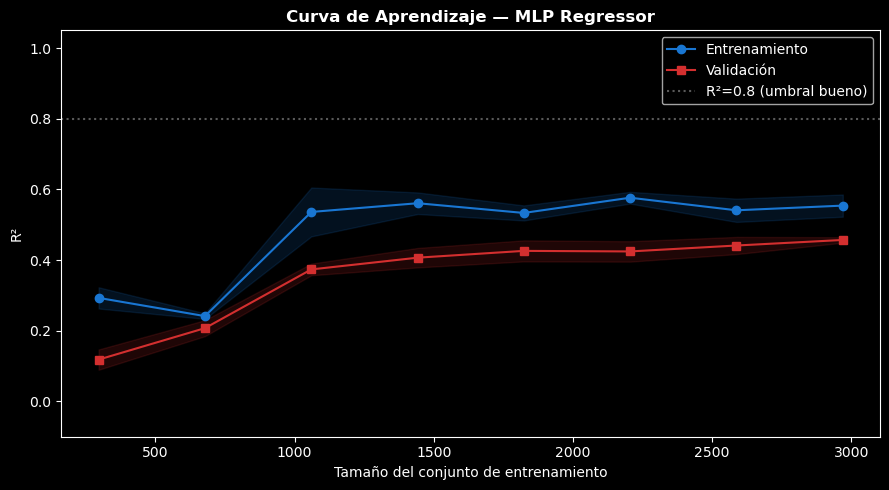

   ⚠️  MLP Regressor: posible UNDERFITTING (val R² = 0.457)


In [44]:
def plot_learning_curve(pipeline, X, y, title, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X, y,
        cv=cv, scoring="r2",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(train_sizes, train_mean, "o-", color="#1976D2", label="Entrenamiento")
    ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std,
                    alpha=0.15, color="#1976D2")
    ax.plot(train_sizes, val_mean, "s-", color="#D32F2F", label="Validación")
    ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std,
                    alpha=0.15, color="#D32F2F")
    ax.axhline(0.8, color="gray", linestyle=":", alpha=0.7, label="R²=0.8 (umbral bueno)")
    ax.set_xlabel("Tamaño del conjunto de entrenamiento")
    ax.set_ylabel("R²")
    ax.set_title(f"Curva de Aprendizaje — {title}", fontweight="bold")
    ax.legend()
    ax.set_ylim(-0.1, 1.05)
    plt.tight_layout()
    plt.show()

    # Diagnóstico automático
    gap = train_mean[-1] - val_mean[-1]
    if gap > 0.15:
        print(f"   ⚠️  {title}: posible OVERFITTING (gap train-val = {gap:.3f})")
    elif val_mean[-1] < 0.6:
        print(f"   ⚠️  {title}: posible UNDERFITTING (val R² = {val_mean[-1]:.3f})")
    else:
        print(f"   ✅ {title}: buen ajuste (val R² = {val_mean[-1]:.3f}, gap = {gap:.3f})")

# Ejecutar para cada modelo optimizado
for name, pipeline in best_models.items():
    plot_learning_curve(pipeline, X_train, y_train, title=name)

---
## 1️⃣5️⃣ Análisis de Residuos

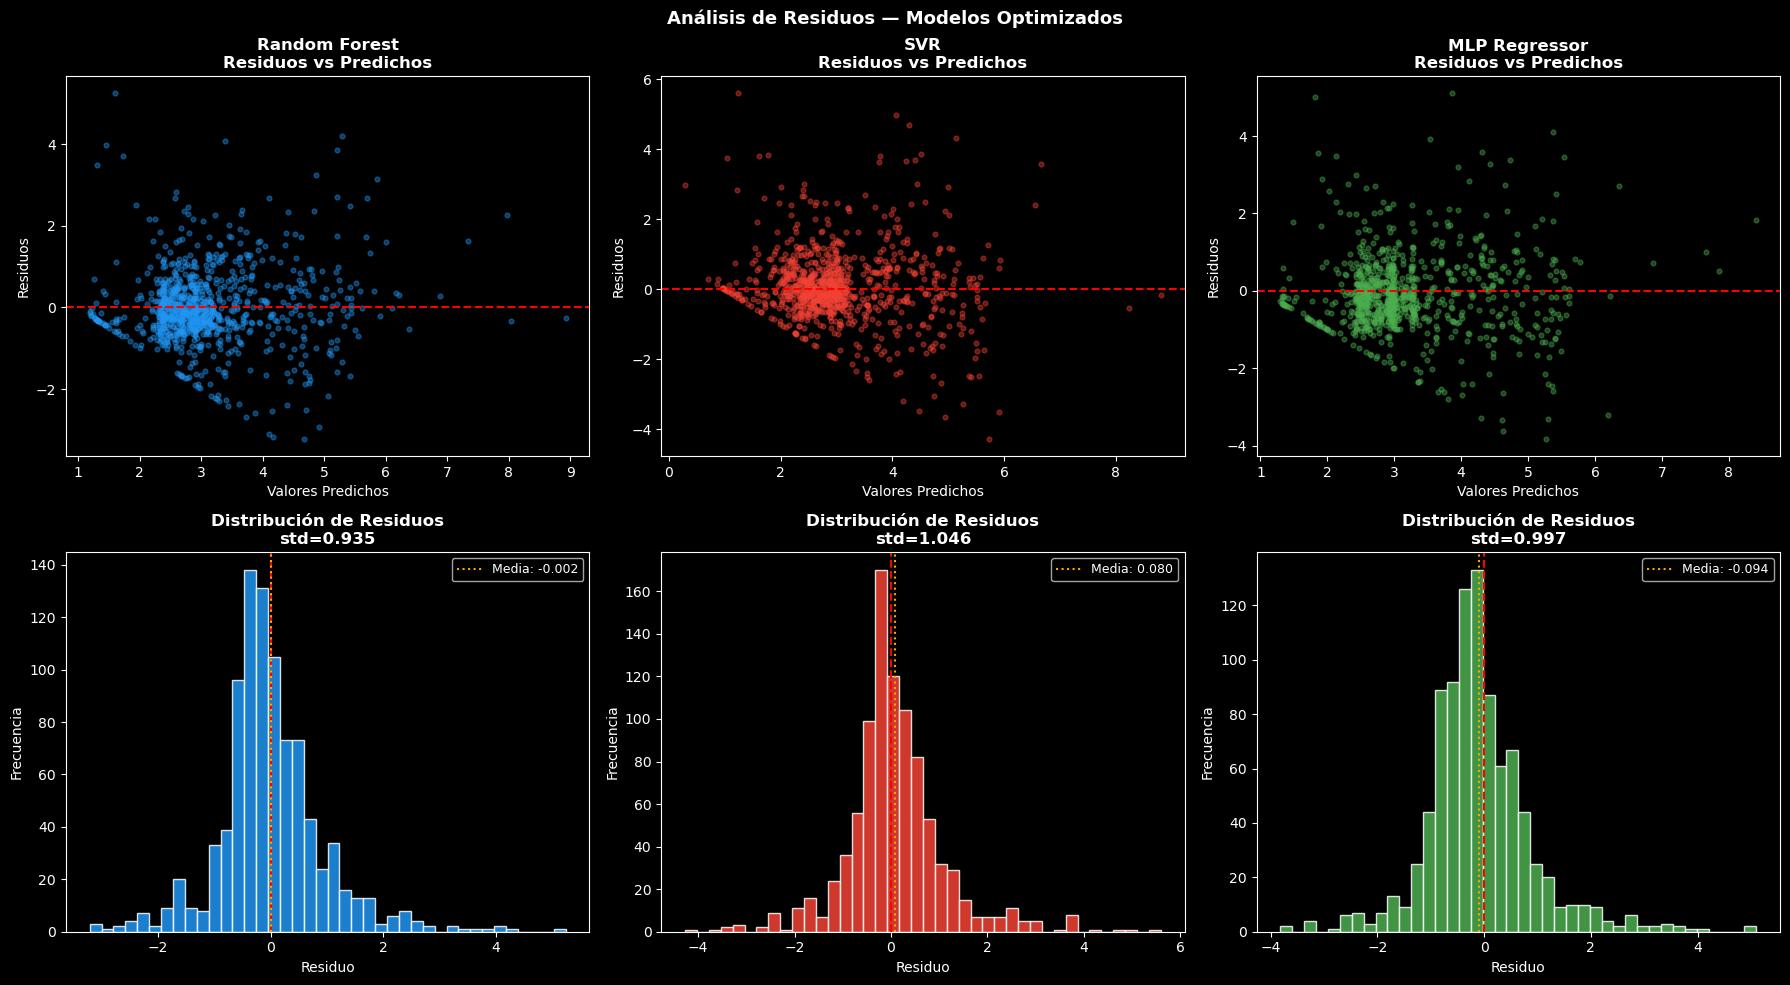

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (name, y_pred) in zip(range(3), predictions_opt.items()):
    residuos = y_test - y_pred

    # Residuos vs predichos
    axes[0, col].scatter(y_pred, residuos, alpha=0.4, s=12,
                         color=model_colors[name])
    axes[0, col].axhline(0, color="red", linestyle="--")
    axes[0, col].set_xlabel("Valores Predichos")
    axes[0, col].set_ylabel("Residuos")
    axes[0, col].set_title(f"{name}\nResiduos vs Predichos", fontweight="bold")

    # Distribución de residuos
    axes[1, col].hist(residuos, bins=40, color=model_colors[name],
                      edgecolor="white", alpha=0.85)
    axes[1, col].axvline(0, color="red", linestyle="--")
    axes[1, col].axvline(residuos.mean(), color="orange", linestyle=":",
                         label=f"Media: {residuos.mean():.3f}")
    axes[1, col].set_xlabel("Residuo")
    axes[1, col].set_ylabel("Frecuencia")
    axes[1, col].set_title(f"Distribución de Residuos\nstd={residuos.std():.3f}",
                            fontweight="bold")
    axes[1, col].legend(fontsize=9)

plt.suptitle("Análisis de Residuos — Modelos Optimizados",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 1️⃣6️⃣ Resumen final y selección del mejor modelo

In [46]:
print("="*65)
print("RESUMEN FINAL — PREDICCIÓN DE inten_ajus")
print("="*65)

df_final_results = pd.DataFrame({
    "MAE_base":  {m: results[m]["MAE"] for m in results},
    "R2_base":   {m: results[m]["R2"]  for m in results},
    "MAE_opt":   {m: results_opt[m]["MAE"] for m in results_opt},
    "RMSE_opt":  {m: results_opt[m]["RMSE"] for m in results_opt},
    "R2_opt":    {m: results_opt[m]["R2"]  for m in results_opt},
}).round(4)

print(df_final_results.to_string())

# Mejor modelo por R²
mejor_modelo = max(results_opt, key=lambda m: results_opt[m]["R2"])
print(f"\n🏆 MEJOR MODELO: {mejor_modelo}")
print(f"   MAE  = {results_opt[mejor_modelo]['MAE']:.4f}")
print(f"   RMSE = {results_opt[mejor_modelo]['RMSE']:.4f}")
print(f"   R²   = {results_opt[mejor_modelo]['R2']:.4f}")
print(f"\n   Hiperparámetros: {best_params[mejor_modelo]}")

print("\n" + "="*65)
print("FEATURES UTILIZADAS EN EL MODELO FINAL")
print("="*65)
print(f"  Numéricas  ({len(NUM_FEATURES)}): {NUM_FEATURES}")
print(f"  Categóricas ({len(CAT_FEATURES)}): {CAT_FEATURES}")
print(f"  Target     : inten_ajus")

RESUMEN FINAL — PREDICCIÓN DE inten_ajus
               MAE_base  R2_base  MAE_opt  RMSE_opt  R2_opt
Random Forest    0.6663   0.5304   0.6533    0.9349  0.5441
SVR              0.7210   0.4490   0.7062    1.0483  0.4268
MLP Regressor    0.7307   0.4679   0.7134    1.0005  0.4778

🏆 MEJOR MODELO: Random Forest
   MAE  = 0.6533
   RMSE = 0.9349
   R²   = 0.5441

   Hiperparámetros: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}

FEATURES UTILIZADAS EN EL MODELO FINAL
  Numéricas  (9): ['MMax', 'Strike', 'Rake', 'Dip', 'lat', 'lon', 'n_replicas_log', 'year', 'es_mainshock_bin']
  Categóricas (1): ['Tipo']
  Target     : inten_ajus
